In [2]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
tokenizer

BertTokenizerFast(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [3]:
!wget https://archive.ics.uci.edu/static/public/176/blood+transfusion+service+center.zip
!unzip blood+transfusion+service+center.zip

--2025-03-26 16:49:01--  https://archive.ics.uci.edu/static/public/176/blood+transfusion+service+center.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘blood+transfusion+service+center.zip’

blood+transfusion+s     [ <=>                ]   3.85K  --.-KB/s    in 0s      

2025-03-26 16:49:01 (864 MB/s) - ‘blood+transfusion+service+center.zip’ saved [3938]

Archive:  blood+transfusion+service+center.zip
  inflating: transfusion.data        
  inflating: transfusion.names       


In [6]:
import pandas as pd

df = pd.read_csv('transfusion.data', sep=',')
print(len(df))
df

748


,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months),whether he/she donated blood in March 2007
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0
...,...,...,...,...,...
743,23,2,500,38,0
744,21,2,500,52,0
745,23,3,750,62,0
746,39,1,250,39,0


In [7]:
df.columns

Index(['Recency (months)', 'Frequency (times)', 'Monetary (c.c. blood)',
       'Time (months)', 'whether he/she donated blood in March 2007'],
      dtype='object')

In [17]:
import numpy as np
import torch

def concatenate_text(x):
    text = "".join([f"I have information about a blood donor. For the first time he donated blood {x['Time (months)']} months ago. ",
           f"Last time he donated blood {x['Recency (months)']} months ago. ",
           f"In total he donated blood {x['Frequency (times)']} times and donated {x['Monetary (c.c. blood)']} cubic centimeters of blood. ",
           f"Will this person donate blood in the next month?"])

    
    return text

concatenate_text(df.iloc[0])

'I have information about a blood donor. For the first time he donated blood 98 months ago. Last time he donated blood 2 months ago. In total he donated blood 50 times and donated 12500 cubic centimeters of blood. Will this person donate blood in the next month?'

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('whether he/she donated blood in March 2007', axis =1),
                                                    df['whether he/she donated blood in March 2007'],
                                                    test_size=.2,
                                                    random_state = 42)
# y_train = y_train.replace({'yes': 1, 'no': 0})
# y_test = y_test.replace({'yes': 1, 'no': 0})

X_train['label'] = y_train
X_test['label'] = y_test

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

In [20]:
X_train['text'].iloc[0]

'I have information about a blood donor. For the first time he donated blood 49 months ago. Last time he donated blood 9 months ago. In total he donated blood 11 times and donated 2750 cubic centimeters of blood. Will this person donate blood in the next month?'

In [21]:
len(X_train)

598

In [22]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 3.3 MB/s eta 0:00:00


In [23]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import numpy as np
import evaluate

# Define label mappings
id2label = {0: "NOT-DONATE", 1: "DONATE"}
label2id = {"NOT-DONATE": 0, "DONATE": 1}

# Convert to Hugging Face Dataset format
train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

def tokenize_function(examples):
    # Adjust based on the structure of your dataset
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

Map:   0%|          | 0/598 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Map:   0%|          | 0/598 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

In [24]:
tokenized_train_dataset[0].keys()

dict_keys(['Recency (months)', 'Frequency (times)', 'Monetary (c.c. blood)', 'Time (months)', 'label', 'text', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'])

In [25]:
tokenized_train_dataset[0]['text']

'I have information about a blood donor. For the first time he donated blood 49 months ago. Last time he donated blood 9 months ago. In total he donated blood 11 times and donated 2750 cubic centimeters of blood. Will this person donate blood in the next month?'

In [26]:
tokenized_train_dataset[0]['label']

1

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Roc Auc
1,8.386300,0.567403,0.591485
2,2.642000,2.786680,0.377661
3,2.381300,0.637089,0.618751
4,1.042700,1.520189,0.488759
5,2.034900,3.329297,0.413059
6,8.158300,6.514286,0.422985
7,3.606200,1.273948,0.578211
8,2.094800,8.922989,0.656302
9,6.751500,0.636592,0.502033
10,3.262600,9.240693,0.586582


{'eval_loss': 0.554578423500061, 'eval_roc_auc': 0.6429083951207846, 'eval_runtime': 0.5811, 'eval_samples_per_second': 258.132, 'eval_steps_per_second': 5.163, 'epoch': 20.0}
test f1 0.0
test precision 0.0
test recall 0.0
test accuracy 0.0
test roc_auc 0.6612054532408514



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


train f1 0.0
train precision 0.0
train recall 0.0
train accuracy 0.7642140468227425
train roc_auc 0.6907134099973617


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


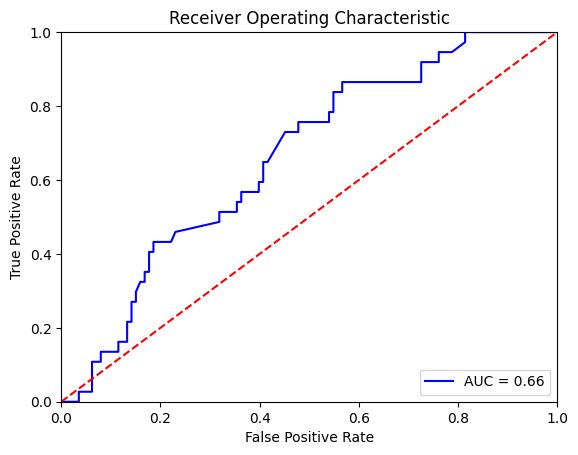

In [43]:
from transformers import BertForSequenceClassification
from transformers import DataCollatorWithPadding
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import roc_curve, auc
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import sklearn.metrics as metrics

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('cuda')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=00,
    learning_rate = 0.1,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

Epoch,Training Loss,Validation Loss,Roc Auc
1,0.525200,0.557865,0.671849
2,0.512500,0.549999,0.669696
3,0.523400,0.547085,0.673403
4,0.523700,0.548827,0.676034
5,0.512200,0.546388,0.674001
6,0.535500,0.542073,0.670175
7,0.515600,0.532752,0.680340
8,0.520300,0.550482,0.673403
9,0.521800,0.520652,0.688472
10,0.522900,0.530210,0.685960


{'eval_loss': 0.5235528349876404, 'eval_roc_auc': 0.7115522602248266, 'eval_runtime': 0.5759, 'eval_samples_per_second': 260.462, 'eval_steps_per_second': 5.209, 'epoch': 20.0}
test f1 0.0975609756097561
test precision 0.5
test recall 0.05405405405405406
test accuracy 0.5
test roc_auc 0.70916048792155



train f1 0.19999999999999998
train precision 0.8421052631578947
train recall 0.11347517730496454
train accuracy 0.7859531772575251
train roc_auc 0.7766267827490415


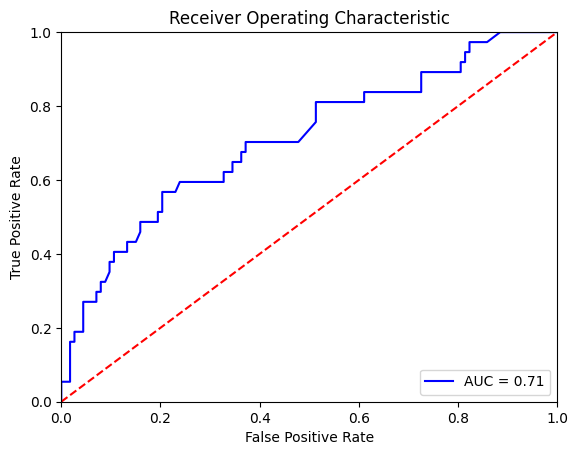

In [45]:
for param in model.bert.parameters():
    param.requires_grad = True

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()